# Portfolio optimization — short window (last 3 months, many stocks)

Last 3 months of daily returns for ~500 stocks ($N > T$). Instead of the rank-deficient sample covariance, we build a **factor-model covariance**: denoise the returns with a rank-$K$ SVD reconstruction and add the idiosyncratic diagonal back,
$$\Sigma = \tfrac{1}{T-1}\tilde X\tilde X^\top + \mathrm{diag}(\Psi),$$
which is **full-rank and well-conditioned** (low-rank signal + idiosyncratic noise). Then long-only mean-variance via softmax.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from stonks import get_prices, to_returns

%matplotlib inline


## Parameters


In [87]:
TOP_N = 500
MONTHS = 3
PERIOD = "2y"      # cached; we slice the last MONTHS from it
INTERVAL = "1d"
gamma = 20.0        # risk aversion


## Fetch, slice last 3 months, compute $\mu$ and $\Sigma$


In [93]:
prices = get_prices(top_n=TOP_N, period=PERIOD, interval=INTERVAL, field="close")
cut = pd.Timestamp(prices.columns[-1]) - pd.DateOffset(months=MONTHS)
returns = to_returns(prices.loc[:, prices.columns >= cut]).dropna()

X = returns.to_numpy(dtype=float)

U, S, Vt = np.linalg.svd(X)
K = 3
X = (U[:,:K]*S[:K]) @ Vt[:K]


tickers = list(returns.index)
N, T = X.shape
mu = X.mean(axis=1)
Xc = X - mu[:, None]

Psi = ((returns.to_numpy(float) - X)**2).sum(1) / (X.shape[1]-1)

Sigma = (Xc @ Xc.T) / (T - 1)
Sigma = Sigma + np.diag(Psi) 
mu_t = torch.tensor(mu, dtype=torch.float64)
Sig_t = torch.tensor(Sigma, dtype=torch.float64)

print(f"N={N} stocks, T={T} days, rank(Sigma)={np.linalg.matrix_rank(Sigma)} (= N, full rank), cond=%.1e"
      % np.linalg.cond(Sigma))


N=453 stocks, T=63 days, rank(Sigma)=453 (= T-1), cond=2.0e+03


In [94]:
# Sigma is now full-rank / invertible, so the closed form works again.
# But it returns *signed* weights (allows shorts), so we still use long-only softmax below.
w_cf = np.linalg.solve(Sigma, mu) / gamma
print(f"closed-form weights: sum={w_cf.sum():.3f}, min={w_cf.min():.3f}, max={w_cf.max():.3f}")
print("(works because Sigma is invertible now; signed -> allows shorts)")

closed-form 'weights': min=-0.00373  max=0.00876  (meaningless - Sigma is singular)


## Long-only optimizer (softmax)

$w=\mathrm{softmax}(z)$ keeps $w\ge0$, $\sum w=1$ — we use it to enforce **long-only** (no shorts), ascending on $z$ via autograd. The factor model already made $\Sigma$ full-rank, so this is no longer about dodging a singular matrix — it's just the clean way to stay long-only.

In [95]:
z = torch.randn(N, dtype=torch.float64, requires_grad=True)
opt = torch.optim.Adam([z], lr=0.5)
for _ in range(8000):
    opt.zero_grad()
    w = torch.softmax(z, dim=0)
    loss = -(mu_t @ w - 0.5 * gamma * w @ Sig_t @ w)
    loss.backward()
    opt.step()

w_long = torch.softmax(z, dim=0).detach().numpy()
ann_ret = w_long @ mu * 252
ann_vol = np.sqrt(w_long @ Sigma @ w_long) * np.sqrt(252)
print(f"holdings(>1e-3)={int((w_long>1e-3).sum())}  ann_ret={ann_ret*100:.1f}%  vol={ann_vol*100:.1f}%  Sharpe={ann_ret/ann_vol:.2f}")
pd.Series(w_long, index=tickers).sort_values(ascending=False).head(10).round(3)


holdings(>1e-3)=339  ann_ret=26.6%  vol=11.6%  Sharpe=2.29


ADP     0.014
PAYX    0.011
CRM     0.010
VEEV    0.009
WDAY    0.009
NOW     0.008
CVX     0.008
MRSH    0.007
ADBE    0.007
PATH    0.007
dtype: float64

Text(0.5, 1.0, 'Long-only weights, $\\gamma$=20 ($\\Sigma$ singular, softmax optimizer)')

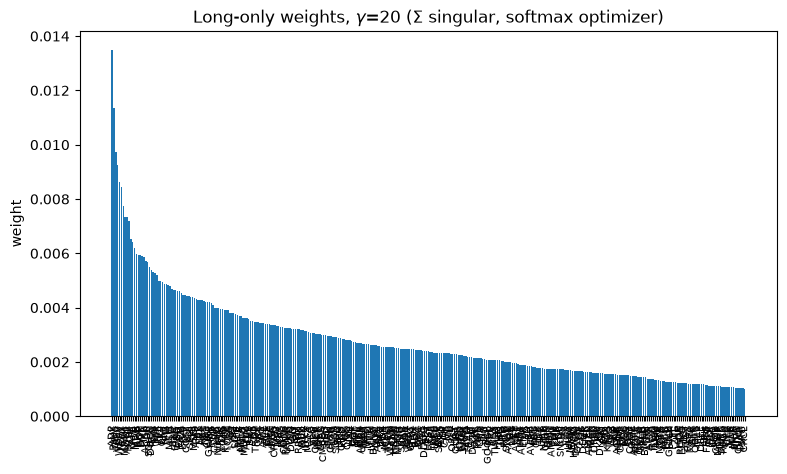

In [96]:
weights = pd.Series(w_long, index=tickers).sort_values(ascending=False)
nz = weights[weights > 1e-3]
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(nz)), nz.values)
ax.set_xticks(range(len(nz))); ax.set_xticklabels(nz.index, rotation=90, fontsize=7)
ax.set_ylabel("weight"); ax.set_title(rf"Long-only weights, $\gamma$={gamma:g} (factor-model $\Sigma$, softmax)")


## Risk-aversion sweep

Higher $\gamma$ penalizes variance harder → lower vol at the cost of lower return (the usual risk/return tradeoff). These are still in-sample numbers, so take the Sharpe with a grain of salt — see `portfolio_oos_test` for the honest out-of-sample check.

In [97]:
print(f"{'gamma':>6} {'holdings':>9} {'ann_ret%':>9} {'vol%':>7} {'Sharpe':>7}")
for g in [2, 10, 50, 200]:
    z = torch.zeros(N, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.Adam([z], lr=0.5)
    for _ in range(8000):
        opt.zero_grad()
        w = torch.softmax(z, dim=0)
        loss = -(mu_t @ w - 0.5 * g * w @ Sig_t @ w)
        loss.backward()
        opt.step()
    w = torch.softmax(z, dim=0).detach().numpy()
    ar = w @ mu * 252
    av = np.sqrt(w @ Sigma @ w) * np.sqrt(252)
    print(f"{g:6d} {int((w > 1e-3).sum()):9d} {ar*100:9.1f} {av*100:7.1f} {ar/av:7.2f}")


 gamma  holdings  ann_ret%    vol%  Sharpe
     2         8     139.4    66.7    2.09
    10       240      52.7    23.0    2.30
    50       300      10.7     4.9    2.19
   200       274       2.9     2.0    1.40
